# Assignment 4 - Portugal
# Eligibility Analysis

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, unicodedata
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt, cartopy.crs as ccrs, cartopy
import atlite, xarray as xr, rasterio, requests
from rasterio.transform import from_bounds
from atlite.gis import ExclusionContainer
from shapely.geometry import box

In [2]:
url_dataset   = 'https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq'
url_airports  = f'{url_dataset}/download?path=%2F&files=ne_10m_airports.gpkg'
url_roads     = f'{url_dataset}/download?path=%2F&files=ne_10m_roads.gpkg'
url_gadm      = f'{url_dataset}/download?path=%2Fgadm&files=gadm_410-levels-ADM_1-PRT.gpkg'
url_wdpa      = f'{url_dataset}/download?path=%2Fwdpa&files=WDPA_Oct2022_Public_shp-PRT.tif'
url_glc       = f'{url_dataset}/download?path=%2Fcopernicus-glc&files=PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-PT.tif'
url_eez       = f'{url_dataset}/download?path=%2Fmarineregions%2FWorld_EEZ_v11_20191118_gpkg&files=eez_v11.gpkg'
url_country_shapes = f'{url_dataset}/download?path=%2F&files=country_shapes.geojson'

## 1. Shapes & Regions

In [3]:
countries = gpd.read_file(url_country_shapes).set_index('name')
country_shape = countries.loc[['PT'], 'geometry'].to_crs(3035)
country_shape

name
PT    POLYGON ((2831438.053 1912762.934, 2830052.451...
Name: geometry, dtype: geometry

In [4]:
regions_raw = gpd.read_file(url_gadm).to_crs(3035)

nuts2_mapping = {
    'Norte':    ['Braga','Braganca','Porto','Viana do Castelo','Vila Real'],
    'Centro':   ['Aveiro','Castelo Branco','Coimbra','Guarda','Leiria','Viseu','Santarem'],
    'Lisboa':   ['Lisboa','Setubal'],
    'Alentejo': ['Beja','Evora','Portalegre'],
    'Algarve':  ['Faro'],
}
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s)) if unicodedata.category(c) != 'Mn')
district_to_nuts2 = {d: k for k, v in nuts2_mapping.items() for d in v}
regions_raw['nuts2'] = regions_raw['NAME_1'].apply(strip_accents).map(district_to_nuts2)
regions = regions_raw.dropna(subset=['nuts2']).dissolve('nuts2')[['geometry']]
regions['representative_point'] = regions.geometry.representative_point()
print(regions)

                                                   geometry  \
nuts2                                                         
Alentejo  MULTIPOLYGON (((2726815.031 1774790.872, 27267...   
Algarve   MULTIPOLYGON (((2642809.829 1757654.459, 26428...   
Centro    MULTIPOLYGON (((2683741.374 1949010.02, 268373...   
Lisboa    MULTIPOLYGON (((2637740.323 1950901.258, 26377...   
Norte     MULTIPOLYGON (((2764029.832 2200543.414, 27640...   

                     representative_point  
nuts2                                      
Alentejo   POINT (2775593.165 1894311.45)  
Algarve   POINT (2710120.511 1766588.899)  
Centro    POINT (2789439.757 2057873.833)  
Lisboa    POINT (2675404.078 1979232.176)  
Norte     POINT (2857288.109 2224000.179)  


In [5]:
fn_eez = 'eez_portugal.gpkg'
if os.path.exists(fn_eez):
    eez = gpd.read_file(fn_eez).to_crs(3035)                        # [EPSG:3035, m]
else:
    eez = gpd.read_file(url_eez).to_crs(3035)                       # [EPSG:3035, m]
    eez = eez[eez['SOVEREIGN1'] == 'Portugal']
    eez.to_file(fn_eez, driver='GPKG')
mb = country_shape.total_bounds                                     # [m]
clip_box = box(mb[0]-300_000, mb[1]-50_000, mb[2]+50_000, mb[3]+50_000)  # [m] mainland bounding box
eez_mainland = eez.clip(clip_box)
print(f'EEZ rows: {len(eez_mainland)}')

EEZ rows: 1


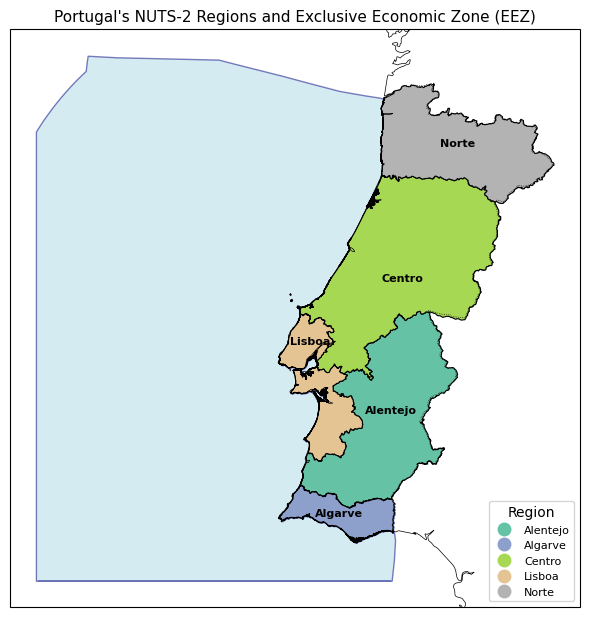

In [23]:
fig, ax = plt.subplots(figsize=(6, 9), subplot_kw={'projection': ccrs.epsg(3035)})
eez_mainland.plot(ax=ax, edgecolor='navy', facecolor='lightblue', alpha=0.5, linewidth=1)
regions.plot(ax=ax, column=regions.index, cmap='Set2', edgecolor='k', linewidth=0.8,
             legend=True, legend_kwds={'loc':'lower right','title':'Region','fontsize':8})
for region, row in regions.iterrows():
    pt = row['representative_point']
    ax.annotate(region, xy=(pt.x, pt.y), ha='center', va='center', fontsize=8, fontweight='bold')
ax.add_feature(cartopy.feature.BORDERS, linewidth=0.5, linestyle=':')
ax.coastlines(resolution='10m', linewidth=0.5)
ax.set_title('Portugal\'s NUTS-2 Regions and Exclusive Economic Zone (EEZ)', fontsize=11)
plt.tight_layout()
plt.savefig('regions_portugal.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Renewable Potentials

In [7]:
cutout = atlite.Cutout(path='portugal-2013.nc', module='era5',
                       x=slice(-10.5, -5.5),   # [deg] longitude range
                       y=slice(36.0, 43.0),    # [deg] latitude range
                       time='2013', dt='1h')   # [h] time resolution
if not cutout.prepared: 
    print('Downloading ERA5...')
    cutout.prepare()
cutout

<Cutout "portugal-2013">
 x = -10.50 ⟷ -5.50, dx = 0.25
 y = 36.00 ⟷ 43.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

In [8]:
suitable_lc  = [10, 20, 30, 40, 60]   # [-] LC100 codes: tree/shrub/herbaceous/cropland/bare
excluded_lc  = [c for c in range(0, 250) if c not in suitable_lc]  # [-]

def eligible_area_km2(avail_matrix):
    cell_area    = cutout.grid.to_crs(3035).area / 1e6              # [km2] per weather cell
    n_y, n_x     = len(cutout.coords['y']), len(cutout.coords['x'])
    cell_area_2d = cell_area.values.reshape(n_y, n_x)               # [km2]
    return pd.Series((avail_matrix.values * cell_area_2d).sum(axis=(1, 2)))  # [km2] per region

def avail_to_matrix(avail):
    return avail.stack(spatial=['y', 'x'])                          # [-]

def download_file(url, local_path):
    if not os.path.exists(local_path):
        r = requests.get(url, stream=True); r.raise_for_status()
        with open(local_path, 'wb') as f:
            for chunk in r.iter_content(1 << 20): f.write(chunk)    
    return local_path

fn_airports = download_file(url_airports, 'ne_10m_airports.gpkg')
fn_roads    = download_file(url_roads,    'ne_10m_roads.gpkg')
fn_glc      = download_file(url_glc,      'lc100_portugal.tif')
fn_wdpa_local = download_file(url_wdpa,   'wdpa_portugal.tif')

In [9]:
# --- Onshore Wind ---
roads_gdf = gpd.read_file(fn_roads)
major_types = ['Major Highway', 'Secondary Highway', 'Beltway', 'Bypass']
roads_major = roads_gdf[roads_gdf['type'].isin(major_types)].to_crs(3035)   # [EPSG:3035, m]

exc_wind = ExclusionContainer(crs=3035, res=100)                            # [m] raster resolution
exc_wind.add_geometry(gpd.read_file(fn_airports).to_crs(3035).geometry, buffer=10_000)  # [m] airport buffer
exc_wind.add_geometry(roads_major.geometry, buffer=300)                     # [m] road buffer
exc_wind.add_raster(fn_wdpa_local, codes=[1],        crs='ESRI:54009')      # protected areas
exc_wind.add_raster(fn_glc,        codes=[50],        crs=4326, buffer=1000, nodata=255)  # [m] urban buffer
exc_wind.add_raster(fn_glc,        codes=excluded_lc, crs=4326, nodata=255) # unsuitable land cover
avail_wind    = cutout.availabilitymatrix(regions.geometry, exc_wind)       # [-]
wind_eligible = eligible_area_km2(avail_wind)                               # [km2]
wind_eligible.index = regions.index
cf_wind = cutout.wind(turbine='Vestas_V112_3MW', matrix=avail_to_matrix(avail_wind),
                      index=regions.index, per_unit=True).resample(time='3h').mean()  # [-] capacity factor
print('Onshore wind eligible [km2]:'); print(wind_eligible.round(0))

Onshore wind eligible [km2]:
nuts2
Alentejo    7195.0
Algarve      992.0
Centro      5333.0
Lisboa       644.0
Norte       2406.0
dtype: float64


In [ ]:
# --- onshore wind eligibility map + regional potential time series ---
from atlite.gis import shape_availability
import rasterio.plot

shape = gpd.GeoSeries([country_shape.union_all()], crs=3035)
masked, transform = shape_availability(shape, exc_wind)             # [-] 
eligible_share = masked.sum() * exc_wind.res**2 / shape.area[0]     # [-] 

fig, ax = plt.subplots(figsize=(5, 8))
ax = rasterio.plot.show(masked, transform=transform, cmap='Blues', ax=ax)
shape.plot(ax=ax, edgecolor='k', color='none', linewidth=1)
ax.set_title(f'Onshore Wind Eligibility ({eligible_share*100:.1f} % usable)')
plt.tight_layout()
plt.show()

# Potential feed-in per region
pot_wind = cf_wind.to_pandas() * (wind_eligible * 3.0)              # [MW]
pot_wind.plot(figsize=(12, 3), title='Onshore Wind: Potential Power per Region (2013)')
plt.ylabel('Power [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [11]:
from shapely.geometry import box as shp_box

# Offshore area: EEZ minus 10km coastal buffer
land_geom  = country_shape.union_all()
eez_geom   = eez_mainland.union_all()
offshore_area = eez_geom.difference(land_geom.buffer(10_000))    # [m] coastal buffer

# Tiling the sea into 2km cells and assigning each to the nearest region
minx, miny, maxx, maxy = offshore_area.bounds                    # [m]
step = 2000                                                      # [m] grid cell size
cells_grid = [shp_box(x, y, x + step, y + step)
              for x in np.arange(minx, maxx, step)
              for y in np.arange(miny, maxy, step)]
grid = gpd.GeoDataFrame(geometry=cells_grid, crs=3035)
grid['geometry'] = grid.geometry.intersection(offshore_area)
grid = grid[~grid.geometry.is_empty].reset_index(drop=True)

cent = grid.copy()
cent['geometry'] = grid.geometry.centroid
cent = gpd.sjoin_nearest(cent, regions[['geometry']].reset_index(), how='left')
grid['nuts2'] = cent['nuts2'].values

offshore_gdf = grid.dissolve(by='nuts2')[['geometry']]
offshore_gdf.index.name = 'nuts2'
print('Offshore regions:', offshore_gdf.index.tolist())

Offshore regions: ['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte']


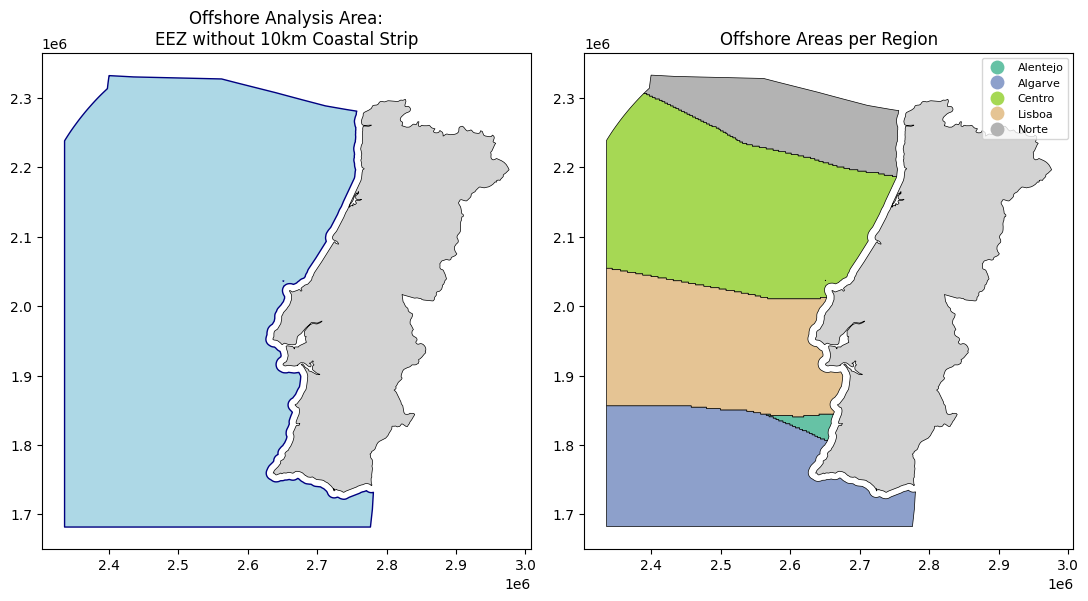

In [12]:
# --- offshore analysis area + region ---
fig, axes = plt.subplots(1, 2, figsize=(11, 8))

# EEZ without 10-km coastal strip
gpd.GeoSeries([offshore_area], crs=3035).plot(ax=axes[0], color='lightblue', edgecolor='navy')
country_shape.plot(ax=axes[0], color='lightgrey', edgecolor='k', linewidth=0.5)
axes[0].set_title('Offshore Analysis Area:\nEEZ without 10km Coastal Strip')

# 2-km cells assigned to nearest NUTS-2 region
offshore_gdf.reset_index().plot(ax=axes[1], column='nuts2', cmap='Set2',
                                 edgecolor='k', linewidth=0.5, legend=True,
                                 legend_kwds={'loc': 'upper right', 'fontsize': 8})
country_shape.plot(ax=axes[1], color='lightgrey', edgecolor='k', linewidth=0.5)
axes[1].set_title('Offshore Areas per Region')
plt.tight_layout()
plt.show()

In [13]:
exc_off = ExclusionContainer(crs=3035, res=100)                  # [m] raster resolution
exc_off.add_raster(fn_wdpa_local, codes=[1], crs='ESRI:54009')   # protected areas
exc_off.add_geometry(country_shape.geometry, buffer=10_000)      # [m] distance to coast

offshore_valid    = offshore_gdf
avail_offshore    = cutout.availabilitymatrix(offshore_valid.geometry, exc_off)  # [-]
offshore_eligible = eligible_area_km2(avail_offshore)            # [km2]
offshore_eligible.index = offshore_valid.index
cf_offshore = cutout.wind(turbine='NREL_ReferenceTurbine_5MW_offshore',
                           matrix=avail_to_matrix(avail_offshore),
                           index=offshore_valid.index, per_unit=True).resample(time='3h').mean()  # [-] capacity factor
print('Offshore wind eligible [km2]:'); print(offshore_eligible.round(0))

Offshore wind eligible [km2]:
nuts2
Alentejo     1838.0
Algarve     27822.0
Centro      21857.0
Lisboa      19343.0
Norte       13304.0
dtype: float64


In [ ]:
# --- offshore eligibility map + regional potential time series ---
shape_off = gpd.GeoSeries([offshore_area], crs=3035)
masked_off, transform_off = shape_availability(shape_off, exc_off)   # [-]
eligible_share_off = masked_off.sum() * exc_off.res**2 / shape_off.area[0]  # [-]

fig, ax = plt.subplots(figsize=(5, 8))
ax = rasterio.plot.show(masked_off, transform=transform_off, cmap='Greens', ax=ax)
shape_off.plot(ax=ax, edgecolor='navy', color='none', linewidth=0.8)
country_shape.plot(ax=ax, color='lightgrey', edgecolor='k', linewidth=0.5)
ax.set_title(f'Offshore Wind Eligibility ({eligible_share_off*100:.1f} % of analysis area)')
plt.tight_layout()
plt.show()

# Potential feed-in per region
pot_off = cf_offshore.to_pandas() * (offshore_eligible * 3.0)        # [MW]
pot_off.plot(figsize=(12, 3), title='Offshore Wind: Potential Power per Region (2013)')
plt.ylabel('Power [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [15]:
# --- Solar PV ---
exc_solar = ExclusionContainer(crs=3035, res=100)                # [m] raster resolution
exc_solar.add_raster(fn_wdpa_local, codes=[1],          crs='ESRI:54009')   # protected areas
exc_solar.add_raster(fn_glc,        codes=excluded_lc,  crs=4326, nodata=255)  # unsuitable land cover
avail_solar    = cutout.availabilitymatrix(regions.geometry, exc_solar)  # [-]
solar_eligible = eligible_area_km2(avail_solar)                  # [km2]
solar_eligible.index = regions.index
cf_solar = cutout.pv(panel='CdTe', orientation='latitude_optimal',
                     matrix=avail_to_matrix(avail_solar),
                     index=regions.index, per_unit=True).resample(time='3h').mean()  # [-] capacity factor
print('Solar PV eligible [km2]:'); print(solar_eligible.round(0))

Solar PV eligible [km2]:
nuts2
Alentejo     9658.0
Algarve      1812.0
Centro      10807.0
Lisboa       2029.0
Norte        4905.0
dtype: float64


In [ ]:
# --- solar eligibility map + regional potential time series ---
masked_sol, transform_sol = shape_availability(shape, exc_solar)     # [-] 
eligible_share_sol = masked_sol.sum() * exc_solar.res**2 / shape.area[0]  # [-] 

fig, ax = plt.subplots(figsize=(5, 8))
ax = rasterio.plot.show(masked_sol, transform=transform_sol, cmap='Oranges', ax=ax)
shape.plot(ax=ax, edgecolor='k', color='none', linewidth=1)
ax.set_title(f'Solar PV Eligibility ({eligible_share_sol*100:.1f} % usable)')
plt.tight_layout()
plt.show()

# Potential feed-in per region
pot_solar = cf_solar.to_pandas() * (solar_eligible * 3.0)            # [MW]
pot_solar.plot(figsize=(12, 3), title='Solar PV: Potential Power per Region (2013)')
plt.ylabel('Power [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [17]:
DENSITY = 3.0                                     # [MW/km2] deployment density
p_nom_max_wind     = wind_eligible     * DENSITY  # [MW]
p_nom_max_offshore = offshore_eligible * DENSITY  # [MW]
p_nom_max_solar    = solar_eligible    * DENSITY  # [MW]
print('p_nom_max wind [MW]:');     print(p_nom_max_wind.round(0))
print('p_nom_max offshore [MW]:'); print(p_nom_max_offshore.round(0))
print('p_nom_max solar [MW]:');    print(p_nom_max_solar.round(0))

p_nom_max wind [MW]:
nuts2
Alentejo    21585.0
Algarve      2975.0
Centro      16000.0
Lisboa       1931.0
Norte        7217.0
dtype: float64
p_nom_max offshore [MW]:
nuts2
Alentejo     5513.0
Algarve     83465.0
Centro      65570.0
Lisboa      58029.0
Norte       39912.0
dtype: float64
p_nom_max solar [MW]:
nuts2
Alentejo    28973.0
Algarve      5437.0
Centro      32421.0
Lisboa       6086.0
Norte       14715.0
dtype: float64


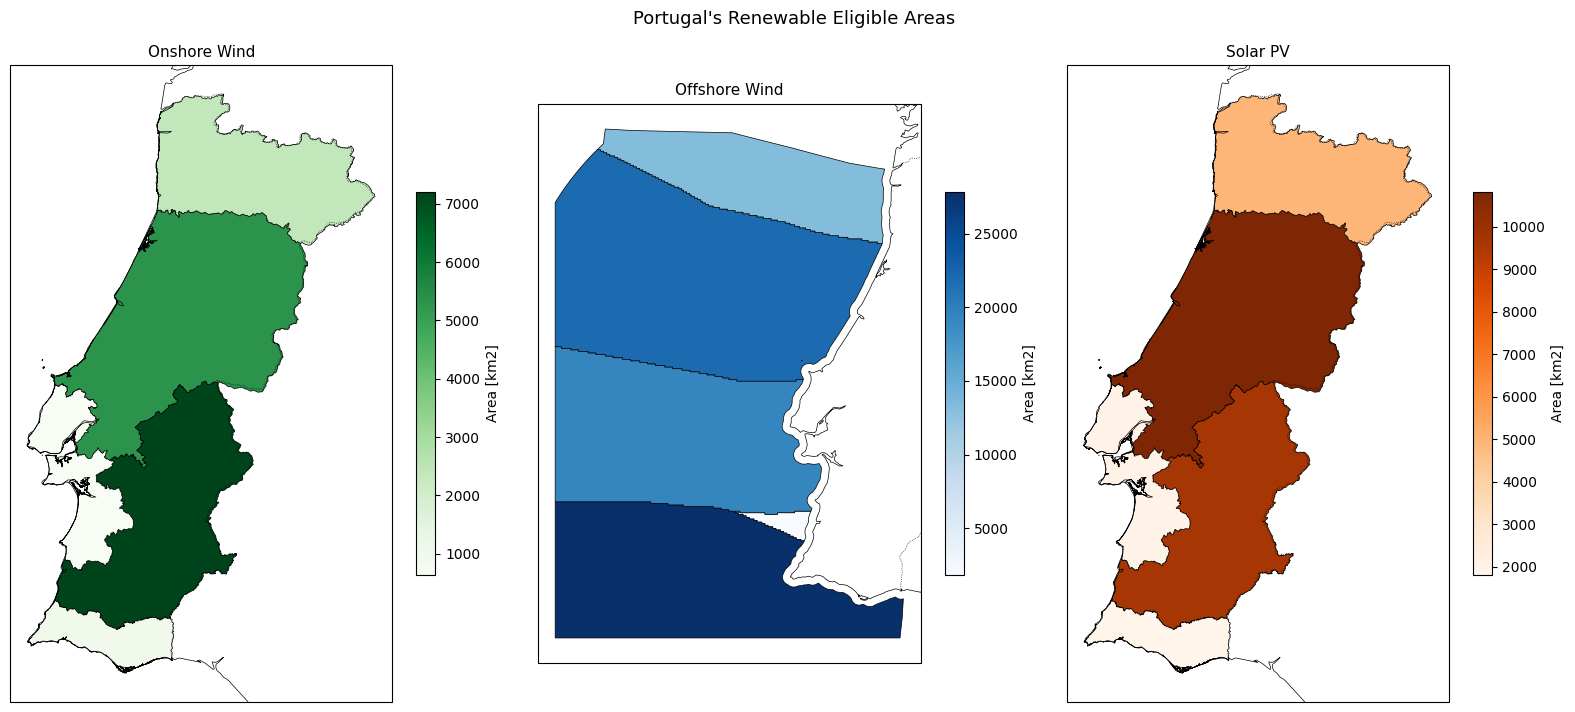

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7), subplot_kw={'projection': ccrs.epsg(3035)})
for ax, title, gdf, elig, cmap in zip(
    axes,
    ['Onshore Wind', 'Offshore Wind', 'Solar PV'],
    [regions, offshore_valid, regions],
    [wind_eligible, offshore_eligible, solar_eligible],
    ['Greens', 'Blues', 'Oranges']
):
    g = gdf.copy(); g['eligible_km2'] = elig.values
    g.plot(ax=ax, column='eligible_km2', cmap=cmap, legend=True,
           legend_kwds={'label': 'Area [km2]', 'shrink': 0.6},
           edgecolor='k', linewidth=0.5)
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.add_feature(cartopy.feature.BORDERS, linewidth=0.5, linestyle=':')
    ax.set_title(title, fontsize=11)
plt.suptitle('Portugal\'s Renewable Eligible Areas', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eligible_areas_portugal.png', dpi=150, bbox_inches='tight')
plt.show()

## Export
Saves data for `PyPSA.ipynb`.

In [19]:
# Regions
regions.drop(columns=['representative_point']).to_file('regions.gpkg', driver='GPKG')  # [EPSG:3035, m]
offshore_valid.to_file('offshore_valid.gpkg', driver='GPKG')     # [EPSG:3035, m]
eez_mainland.to_file('eez_mainland.gpkg', driver='GPKG')         # [EPSG:3035, m]

# Capacity factor time series (3h resolution)
cf_wind.to_netcdf('cf_wind.nc')                                  # [-] 
cf_solar.to_netcdf('cf_solar.nc')                                # [-] 
cf_offshore.to_netcdf('cf_offshore.nc')                          # [-] 

# p_nom_max
p_nom_max_wind.to_csv('p_nom_max_wind.csv',      header=['p_nom_max_MW'])   # [MW]
p_nom_max_solar.to_csv('p_nom_max_solar.csv',    header=['p_nom_max_MW'])   # [MW]
p_nom_max_offshore.to_csv('p_nom_max_offshore.csv', header=['p_nom_max_MW'])  # [MW]